# Swarm Data Fusion toolbox demo notebook

**SwarmDF is a Python tool providing an end-to-end automated framework for data fusion, reconstruction and validation. SwarmDF enables interpretation of Swarm observations within their broader electrodynamic context, supporting better-constrained scientific studies of high-latitude ionospheric electrodynamics.**

This notebook serves as documentation for the SwarmDF Python module. It guides the reader step by step through a typical SwarmDF run.

Alternatively, users may run SwarmDF_GUI.py from a terminal to access a graphical user interface. The GUI is designed to be user-friendly and does not require prior familiarity with the package. It provides the outputs needed for further analysis.

## Imports

In [1]:
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import Image, display
from pathlib import Path

from swarmdf import *


In [2]:
package_root = Path.cwd().parents[2]
output_dir = package_root / "outputs"

## Input

### Main input

Start by choosing a Swarm satellite and defining the time interval for the study.  
This is the only input required before SwarmDF can run. All additional parameters have default values.

In [3]:
sat_id = 'B'
start = datetime(2014, 12, 15, 1, 10, 0)
end   = datetime(2014, 12, 15, 1, 20, 0)
time_step = 30 # [s]

### Datasets


Choose datasets among SuperDARN, SuperMAG, Iridium/Ampere, Swarm electric field and Swarm magnetic field. By default, all datasets are selected. 

In [4]:
datasets2download = ['superdarn', 'supermag', 'iridium_ampere', 'swarm_mag', "swarm_efield", "dmsp_ssies17", "dmsp_ssies18"]

### Grid

Define the extent, spatial resolution, and temporal spacing of the successive 2D regions surrounding the selected Swarm satellite along its trajectory.
Has to be defined as a dictionary.

In [ ]:
grid_params = {"L": 2000, # along track.. km 
               "W": 1500, # km
               "Lres": 200, # km
               "Wres": 200, # km
               "wshift": 0}

### Conductance

! Coductances are a major input for Lompe. 
Define the model of your choice. 

In [10]:
conductance_method = 'Zang & Paxton model'

kp_value = 4
f107_value = 100
background_value = 2 

conductance_params = {"kp": kp_value, "f107": f107_value, "background": background_value}

## Data fusion 

!! 
using sample input datasets
collect swarm data + collect additional data around swarm satellite track within grid + show trajectory and data distribution

The script data_collect.py runs in the background, it checks if the datafiles requested by the user already exist in their data folder, and downloads the files if not. 

SwarmDF will gather Swarm orbit data together with the additional datasets and perform Lompe analyses on those grids, with a default temporal spacing of 30 s between successive grids/analyses.

In [11]:
######################
# Collect data
######################

datahandler = DataManager(start, end, datasets2download, demo = False) # Turn demo to True if you want to skip data collection and use sample datasets for example event 2014-12-15
datasets = datahandler.datasets

Downloading/retrieving data...
Swarm MAG file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_swarm_mag.h5.
DMSP/SSIES F18 file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_ssies_f18.h5
SuperMAG file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_supermag.h5.
Iridium/AMPERE file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_iridium.h5.
DMSP/SSIES F17 file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_ssies_f17.h5
SuperDARN file already exists at /Users/margot/Docs/Academia/Research/Python/SwarmDF/data/20141215_superdarn_grdmap.h5.
Loading data...
swarm_mag dataset loaded.
No file found for swarm_efield
superdarn dataset loaded.
supermag dataset loaded.
iridium_ampere dataset loaded.
dmsp_ssies17 dataset loaded.
dmsp_ssies18 dataset loaded.


Prepare the input to Lompe...

In [12]:
lompe_input = LompeInput(sat_id, start, end, datasets)
grids, analysis_times = lompe_input.build_grids_around_swarm(time_step, grid_params)
data_objects_per_grid = lompe_input.prepare_lompe_input(grids, analysis_times) 

Preparing Lompe input...
Time interval around Swarm center time (2014-12-15 01:10:50): 2014-12-15 01:08:40 - 2014-12-15 01:12:40
Time interval around Swarm center time (2014-12-15 01:11:20): 2014-12-15 01:09:10 - 2014-12-15 01:13:10
Time interval around Swarm center time (2014-12-15 01:11:50): 2014-12-15 01:09:40 - 2014-12-15 01:13:40
Time interval around Swarm center time (2014-12-15 01:12:20): 2014-12-15 01:10:10 - 2014-12-15 01:14:10
Time interval around Swarm center time (2014-12-15 01:12:50): 2014-12-15 01:10:40 - 2014-12-15 01:14:40
Time interval around Swarm center time (2014-12-15 01:13:20): 2014-12-15 01:11:10 - 2014-12-15 01:15:10
Time interval around Swarm center time (2014-12-15 01:13:50): 2014-12-15 01:11:40 - 2014-12-15 01:15:40
Time interval around Swarm center time (2014-12-15 01:14:20): 2014-12-15 01:12:10 - 2014-12-15 01:16:10
Time interval around Swarm center time (2014-12-15 01:14:50): 2014-12-15 01:12:40 - 2014-12-15 01:16:40
Time interval around Swarm center time 

... And plot it

/Users/margot/Docs/Academia/Research/Python/secsy/src/secsy/csplot.py:585: RuntimeWarning: Mean of empty slice
  return np.rad2deg(np.arctan2(np.nanmean(np.sin(np.deg2rad(X)),axis=axis),np.nanmean(np.cos(np.deg2rad(X)),axis=axis)))
/Users/margot/Docs/Academia/Research/Python/secsy/src/secsy/csplot.py:229: RuntimeWarning: Mean of empty slice
  lat_mean = np.nanmean(np.where(~iii,np.nan,lat[:,None]),axis=0) # mean of lat grid lines


Figures with Swarm tracks, analysis grid, and data distribution for each time step saved in: /Users/margot/Docs/Academia/Research/Python/SwarmDF/outputs/tmp
GIF saved in outputs directory as: /Users/margot/Docs/Academia/Research/Python/SwarmDF/outputs/lompe-input_swarmB.gif


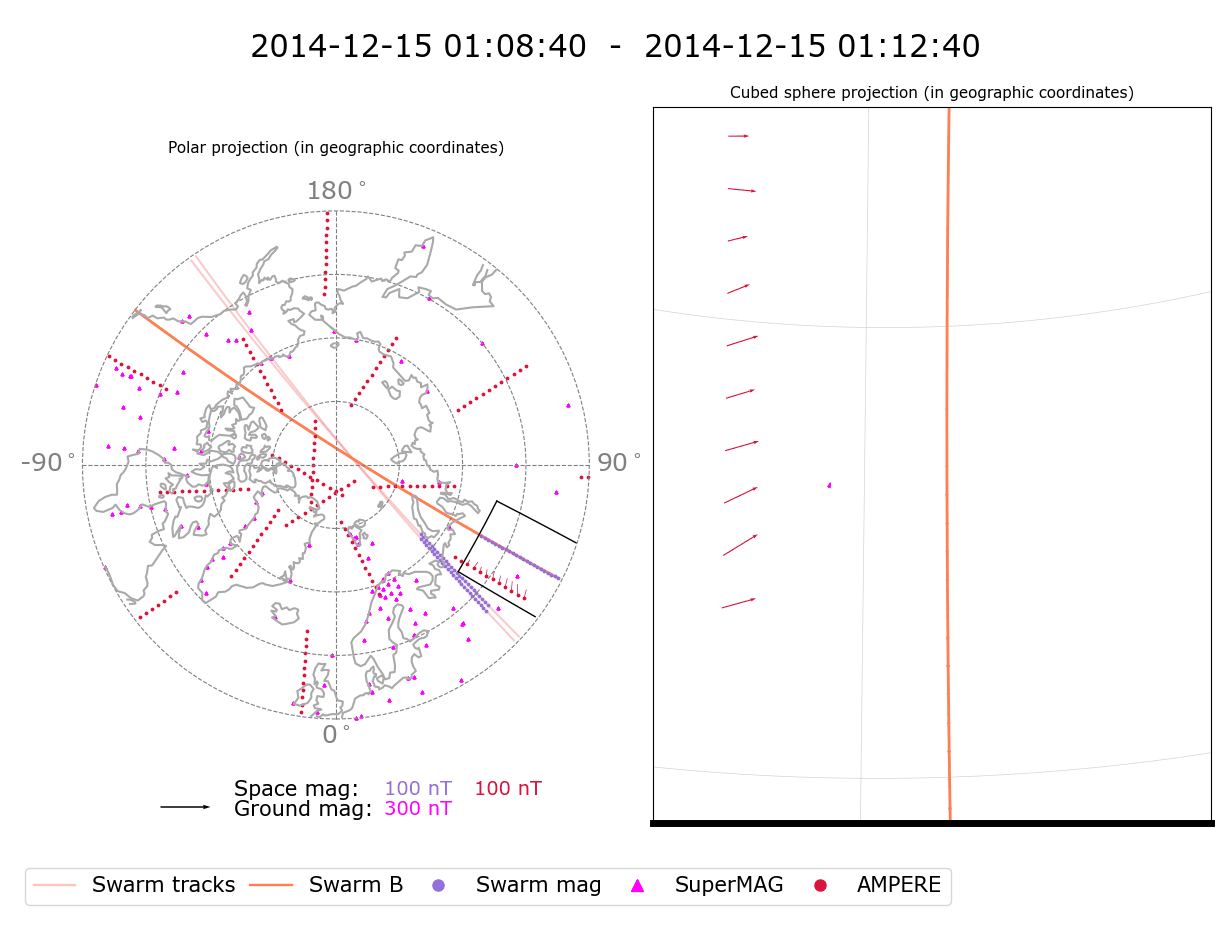

In [13]:
input_frames = lompe_input.plot_lompe_input(grids, analysis_times, data_objects_per_grid, show_global_data=True)

gif_path = output_dir / f"lompe-input_swarm{sat_id}.gif"
display(Image(filename=gif_path))

## Run Lompe analysis

Define conductance

In [ ]:
SHs, SPs = compute_conductances(conductance_method, analysis_times, grids, conductance_params)

Create Lompe Emodel, run inversion and plot reconstructed electrodynamics

In [ ]:
# Regularization parameters for Lompe analysis
l1, l2 = 1, 1

lompe_models = run_lompe(analysis_times, grids, data_objects_per_grid, SHs, SPs, l1, l2)

In [ ]:
output_frames = plot_lompe_output(lompe_models, sat_id) 

gif_path = output_dir / f"lompe-output_swarm{sat_id}.gif"
display(Image(filename=gif_path))